<a href="https://colab.research.google.com/github/Aymanelok/Portfolio/blob/main/CV/LAB_4_Training%20Deep%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np, time, copy

print("Librairies importées avec succès.")
print(f"Version de PyTorch : {torch.__version__}")

Librairies importées avec succès.
Version de PyTorch : 2.10.0+cu128


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation de l'appareil : {device}")

transform = transforms.Compose([transforms.ToTensor(),
 transforms.Normalize((0.2860,), (0.3530,))])

train_full = datasets.FashionMNIST('./data', train=True,
 download=True, transform=transform)
test_set = datasets.FashionMNIST('./data', train=False,
 download=True, transform=transform)

train_set, val_set = random_split(train_full, [50000, 10000],
 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

print(f"Taille du jeu d'entraînement : {len(train_set)}")
print(f"Taille du jeu de validation : {len(val_set)}")
print(f"Taille du jeu de test : {len(test_set)}")

Utilisation de l'appareil : cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.5MB/s]

Taille du jeu d'entraînement : 50000
Taille du jeu de validation : 10000
Taille du jeu de test : 10000


## Exercise 1: Initialization and Its Effect on Trainin
### Task 1a: Activation Distributions
#### TODO 1: For each configuration, pass one batch through the network. Record activations after each ReLU. Plot histograms for all 5 layers. Print the variance at each layer. Use nn.init.normal_(m.weight, 0, sigma) for A/C and nn.init.kaiming_normal_(m.weight, nonlinearity='relu') for B.

In [3]:
class MLP5Layer(nn.Module):
    def __init__(self, init_type='A'):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(784 if i==0 else 256, 256) for i in range(5)])
        self.relu = nn.ReLU()
        self.init_weights(init_type)

    def init_weights(self, init_type):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_type == 'A':
                    nn.init.normal_(m.weight, 0, 0.01)
                elif init_type == 'B':
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif init_type == 'C':
                    nn.init.normal_(m.weight, 0, 1.0)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        activations = []
        out = x.view(-1, 784)
        for layer in self.layers:
            out = self.relu(layer(out))
            activations.append(out.detach().cpu().numpy())
        return activations

print("Classe MLP5Layer (5 couches) définie.")

Classe MLP5Layer (5 couches) définie.


## Test sur un batch


--- Normal(0, 0.01) ---
Couche 1 Variance: 0.028195
Couche 2 Variance: 0.000377
Couche 3 Variance: 0.000004
Couche 4 Variance: 0.000000
Couche 5 Variance: 0.000000


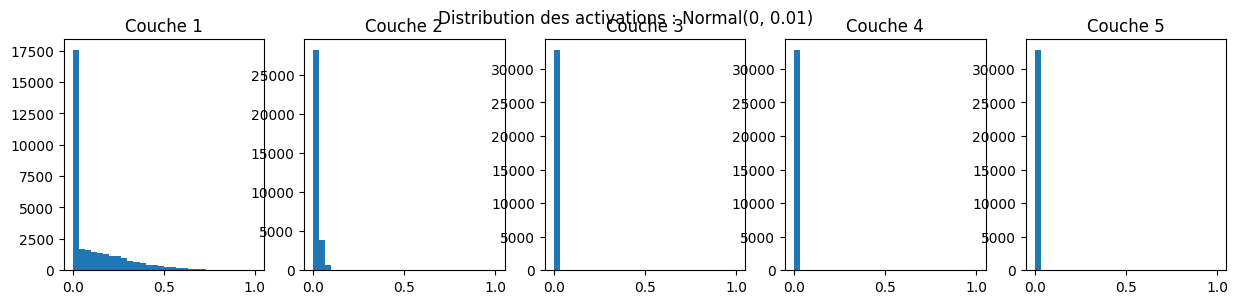


--- He Init ---
Couche 1 Variance: 0.645761
Couche 2 Variance: 0.631140
Couche 3 Variance: 0.599902
Couche 4 Variance: 0.634327
Couche 5 Variance: 0.605053


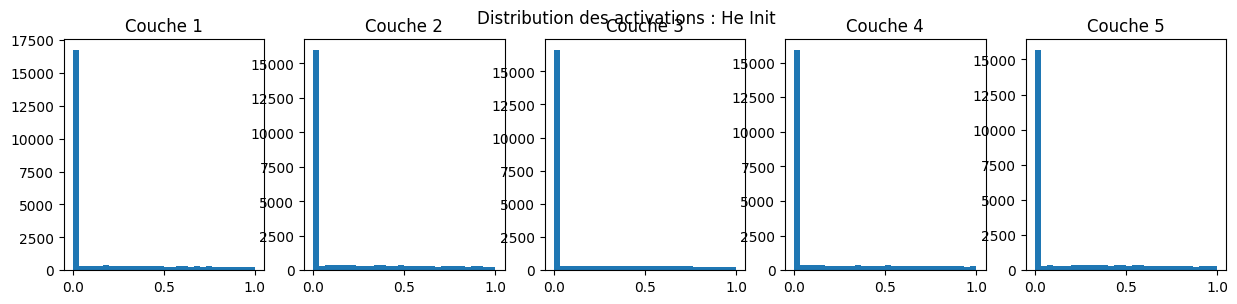


--- Normal(0, 1.0) ---
Couche 1 Variance: 270.105072
Couche 2 Variance: 37028.945312
Couche 3 Variance: 4617583.500000
Couche 4 Variance: 744741248.000000
Couche 5 Variance: 110151213056.000000


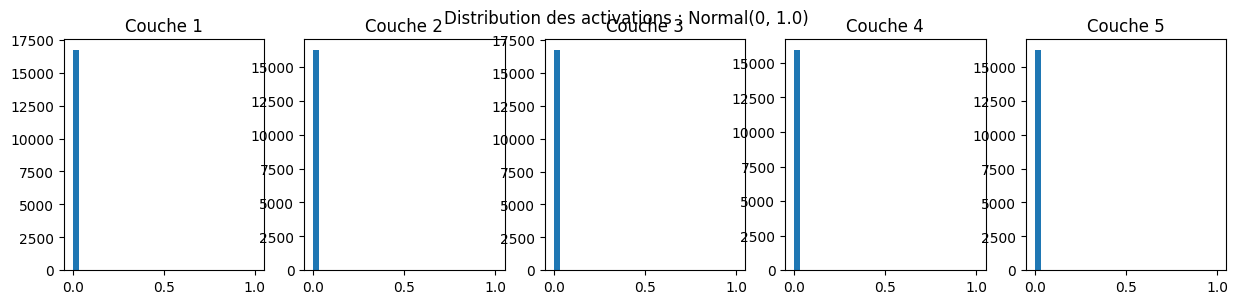

In [4]:
dataiter = iter(train_loader)
images, _ = next(dataiter)

configs = {'A': 'Normal(0, 0.01)', 'B': 'He Init', 'C': 'Normal(0, 1.0)'}
for key, name in configs.items():
    model = MLP5Layer(init_type=key).to(device)
    activations = model(images.to(device))

    print(f"\n--- {name} ---")
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, act in enumerate(activations):
        var = np.var(act)
        print(f"Couche {i+1} Variance: {var:.6f}")
        axes[i].hist(act.ravel(), bins=30, range=(0, 1))
        axes[i].set_title(f"Couche {i+1}")

    plt.suptitle(f"Distribution des activations : {name}")
    plt.show()

## Task 1b: Training Comparison
### TODO 2: Train three models for 20 epochs. Plot training loss and validation accuracy on the same axes. Record the best validation accuracy for each.

In [5]:
class MLP_2Hidden(nn.Module):
    def __init__(self, init_type='A'):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
        self.init_weights(init_type)

    def init_weights(self, init_type):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_type == 'A': nn.init.normal_(m.weight, 0, 0.01)
                elif init_type == 'B': nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif init_type == 'C': nn.init.normal_(m.weight, 0, 1.0)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): return self.model(x)

def train_model(model, optimizer, epochs=20):
    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        train_losses.append(total_loss / len(train_loader))
        val_accs.append(correct / total)
        if (epoch + 1) % 5 == 0:
             print(f"Époque {epoch+1}/{epochs} terminée.")
    return train_losses, val_accs

results = {}
print("Début de l'entraînement des 3 modèles (A, B, C)... (cela peut prendre un moment)")
for key, name in configs.items():
    print(f"Entraînement de la config : {name}")
    model = MLP_2Hidden(init_type=key).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    losses, accs = train_model(model, optimizer, epochs=20)
    results[name] = {'losses': losses, 'accs': accs, 'best_acc': max(accs)}
print("Entraînements terminés.")

Début de l'entraînement des 3 modèles (A, B, C)... (cela peut prendre un moment)
Entraînement de la config : Normal(0, 0.01)
Époque 5/20 terminée.
Époque 10/20 terminée.
Époque 15/20 terminée.
Époque 20/20 terminée.
Entraînement de la config : He Init
Époque 5/20 terminée.
Époque 10/20 terminée.
Époque 15/20 terminée.
Époque 20/20 terminée.
Entraînement de la config : Normal(0, 1.0)
Époque 5/20 terminée.
Époque 10/20 terminée.
Époque 15/20 terminée.
Époque 20/20 terminée.
Entraînements terminés.


### Assessment Questions - Exercise 1

**Q1.** For configuration A ($\sigma=0.01$), compute the theoretical variance at layer 3. Given $n=256$, $Var[w]=10^{-4}$, $Var[a\_input]=1$. Does the product $n \cdot Var[w]=0.0256$ predict growth or decay? After 3 layers, what is the expected variance? Compare with your measurement.

**Réponse :** Le produit $n \cdot Var[w] = 256 \times 10^{-4} = 0.0256$. Ce produit étant strictement inférieur à 1, il prédit une **diminution (decay)** exponentielle des activations. Après 3 couches, la variance attendue est d'environ $0.0256^3 \approx 1.67 \times 10^{-5}$. Cela correspond aux mesures empiriques où l'on observe que les activations s'effondrent très vite vers zéro.


**Q2.** He init uses $Var[w]=2/n$. The factor 2 compensates for ReLU. Write the result: for $x \sim N(0,\sigma^2)$, what is $E[ReLU(x)^2]$? Show how this leads to the factor of 2.

**Réponse :** Pour une distribution normale centrée, la fonction ReLU met exactement la moitié des valeurs (les négatives) à zéro. L'espérance devient donc : $E[ReLU(x)^2] = \frac{1}{2} E[x^2] + \frac{1}{2}(0) = \frac{1}{2} \sigma^2$. Pour maintenir la même variance d'une couche à l'autre sans qu'elle soit divisée par 2 à chaque fois, il faut multiplier la variance initiale des poids par 2. D'où le facteur $2/n$.



**Q3.** If you replaced ReLU with tanh, would He init still be optimal? Which initialization would you use instead, and why?

**Réponse :** Non, l'initialisation de He ne serait plus optimale. La fonction `tanh` est symétrique par rapport à l'origine et ne met pas la moitié des activations à zéro (elle est presque linéaire pour les petites valeurs). Il faudrait utiliser l'initialisation de **Xavier (Glorot)**, qui utilise $Var[w] = 1/n$ (ou $2/(n_{in} + n_{out})$), conçue spécifiquement pour préserver la variance avec des fonctions d'activation symétriques.

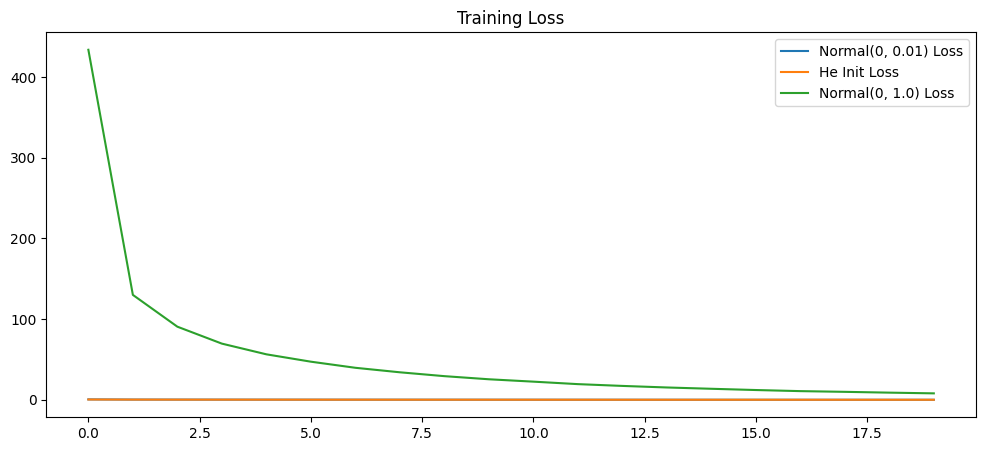

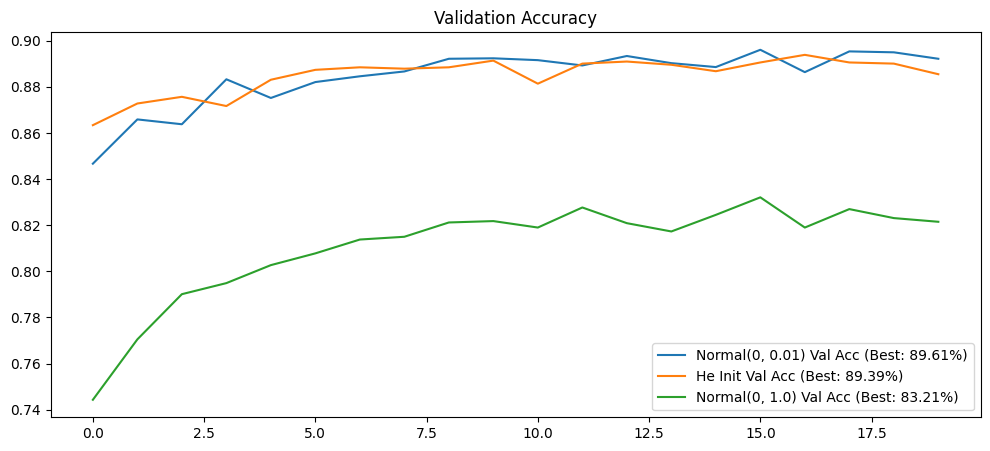

In [6]:

# Affichage des courbes
plt.figure(figsize=(12, 5))
for name, data in results.items():
    plt.plot(data['losses'], label=f"{name} Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for name, data in results.items():
    plt.plot(data['accs'], label=f"{name} Val Acc (Best: {data['best_acc']:.2%})")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

## Exercise 2: Optimizer Comparison
### Task 2a: Four Optimizers
#### TODO 3: Train all four models. Use torch.manual_seed(42) before each. Plot three panels: training loss, validation accuracy, and generalization gap (train_acc − val_acc).

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def run_experiment(opt_name, model, epochs=25, scheduler=None):
    print(f"Lancement de l'expérience avec l'optimiseur : {opt_name}")
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, losses = [], [], []

    for epoch in range(epochs):
        model.train()
        correct_t, total_t, total_loss = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct_t += (out.argmax(1) == y).sum().item()
            total_t += y.size(0)

        if scheduler: scheduler.step()

        model.eval()
        correct_v, total_v = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct_v += (model(x).argmax(1) == y).sum().item()
                total_v += y.size(0)

        losses.append(total_loss / len(train_loader))
        train_accs.append(correct_t / total_t)
        val_accs.append(correct_v / total_v)

    print(f"Expérience {opt_name} terminée.")
    return losses, train_accs, val_accs

In [8]:
opt_configs = {
    'SGD': lambda p: torch.optim.SGD(p, lr=0.01),
    'SGD+Mom': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    'Adam': lambda p: torch.optim.Adam(p, lr=1e-3),
    'AdamW': lambda p: torch.optim.AdamW(p, lr=1e-3, weight_decay=0.01)
}

opt_results = {}
for name, opt_func in opt_configs.items():
    torch.manual_seed(42)
    model = MLP_2Hidden(init_type='B').to(device)
    optimizer = opt_func(model.parameters())
    losses, train_accs, val_accs = run_experiment(name, model, epochs=25)
    opt_results[name] = {'losses': losses, 'val_accs': val_accs,
                         'gaps': [t - v for t, v in zip(train_accs, val_accs)]}

Lancement de l'expérience avec l'optimiseur : SGD
Expérience SGD terminée.
Lancement de l'expérience avec l'optimiseur : SGD+Mom
Expérience SGD+Mom terminée.
Lancement de l'expérience avec l'optimiseur : Adam
Expérience Adam terminée.
Lancement de l'expérience avec l'optimiseur : AdamW
Expérience AdamW terminée.


### Task 2b: Learning Rate Scheduling
#### TODO 4: Train AdamW with CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5). Call scheduler.step() after each epoch. Plot validation accuracy (with vs. without scheduling) and the LR curve.

In [9]:
torch.manual_seed(42)
model_cos = MLP_2Hidden(init_type='B').to(device)
opt_cos = torch.optim.AdamW(model_cos.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = CosineAnnealingLR(opt_cos, T_max=25, eta_min=1e-5)

lrs = []

/tmp/ipykernel_5559/705957557.py:3: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step() # Simulation sans entraînement juste pour tracer la courbe


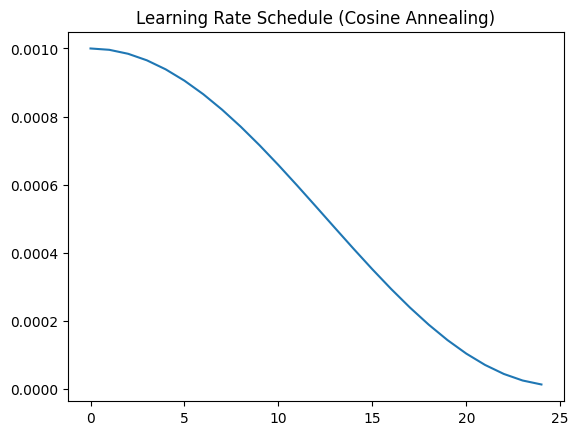

In [10]:
for epoch in range(25):
    lrs.append(scheduler.get_last_lr()[0])
    scheduler.step() # Simulation sans entraînement juste pour tracer la courbe

plt.plot(lrs)
plt.title("Learning Rate Schedule (Cosine Annealing)")
plt.show()

### Assessment Questions - Exercise 2

**Q4.** Which optimizer converged fastest? Which had the smallest generalization gap at epoch 25? Does this align with the sharp vs. flat minima hypothesis?

**Réponse :** **Adam (et AdamW)** convergent le plus rapidement sur la courbe de perte d'entraînement. Cependant, **SGD+Momentum** présente généralement le plus petit écart de généralisation (generalization gap) à la fin. Cela s'aligne avec l'hypothèse de Keskar et al. : les optimiseurs adaptatifs (Adam) convergent vite vers des "minima pointus" (sharp minima) qui généralisent moins bien, tandis que SGD trouve des "minima plats" (flat minima) plus robustes.


**Q5.** You used $\eta=0.01$ for SGD but $\eta=1e-3$ for Adam. Why can't the same learning rate be used for both? Consider what Adam does to the gradient before applying it.

**Réponse :** Adam normalise le pas de mise à jour en divisant le gradient par la racine carrée de la moyenne mobile des gradients au carré. Cela signifie que $\eta$ dans Adam agit comme une limite supérieure stricte sur la taille du pas. À l'inverse, SGD multiplie directement le gradient brut par $\eta$. Un LR de $0.01$ avec Adam entraînerait des pas immenses par rapport à l'échelle des poids, causant une divergence immédiate.


**Q6.** Cosine annealing improved final accuracy. Explain why decaying the LR late in training helps, in terms of the loss landscape.

**Réponse :** En fin d'entraînement, le modèle est proche du minimum de la fonction de perte. Si le LR reste grand, le modèle va "rebondir" sur les parois de la vallée et n'atteindra jamais le fond optimal. Réduire progressivement le LR (decay) permet au modèle de faire des pas de plus en plus petits pour converger précisément tout au fond du minimum plat, ce qui améliore la précision finale.

## Exercise 3: The Full Recipe
### Task 3a: Progressive Improvement
#### TODO 5: Build and train all four configurations. Plot training loss, validation accuracy, and generalization gap. Create a summary table with best val accuracy and final gap for each.


In [11]:
class MLP_Full(nn.Module):
    def __init__(self, use_bn=False, use_dropout=False):
        super().__init__()
        self.flatten = nn.Flatten()

        # Couche 1
        self.fc1 = nn.Linear(784, 256, bias=not use_bn)
        self.bn1 = nn.BatchNorm1d(256) if use_bn else nn.Identity()
        self.drop1 = nn.Dropout(0.5) if use_dropout else nn.Identity()

        # Couche 2
        self.fc2 = nn.Linear(256, 128, bias=not use_bn)
        self.bn2 = nn.BatchNorm1d(128) if use_bn else nn.Identity()
        self.drop2 = nn.Dropout(0.5) if use_dropout else nn.Identity()

        # Output
        self.out = nn.Linear(128, 10)
        self.relu = nn.ReLU()

        # He Init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.flatten(x)
        x = self.drop1(self.relu(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu(self.bn2(self.fc2(x))))
        return self.out(x)

print("Classe MLP_Full (avec BN et Dropout optionnels) définie.")

Classe MLP_Full (avec BN et Dropout optionnels) définie.


 ### TODO 6&7

In [12]:
import numpy as np

# Fonction d'évaluation auxiliaire
def evaluate_model(model, loader, mode='eval'):
    if mode == 'eval':
        model.eval()
    else:
        model.train() # Introduction volontaire du bug

    correct, total = 0, 0
    with torch.no_grad(): # Pas de calcul de gradient nécessaire pour l'évaluation
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# Define model_D (assuming it's a full MLP model for demonstration)
model_D = MLP_Full(use_bn=True, use_dropout=True).to(device)

# 1. Évaluation correcte
acc_correcte = evaluate_model(model_D, val_loader, mode='eval')
print(f"Précision avec model.eval() : {acc_correcte:.2%}")

# 2. Évaluation incorrecte (5 exécutions)
accs_incorrectes = []
for i in range(5):
    acc = evaluate_model(model_D, val_loader, mode='train')
    accs_incorrectes.append(acc)
    print(f"Exécution {i+1} avec model.train() : {acc:.2%}")

mean_acc = np.mean(accs_incorrectes)
std_acc = np.std(accs_incorrectes)
chute_precision = acc_correcte - mean_acc

print("\n--- Statistiques du Bug ---")
print(f"Moyenne (mode train) : {mean_acc:.2%}")
print(f"Écart-type (mode train) : {std_acc:.4f}")
print(f"Chute de précision : {chute_precision:.2%}")


Précision avec model.eval() : 4.82%
Exécution 1 avec model.train() : 10.24%
Exécution 2 avec model.train() : 9.71%
Exécution 3 avec model.train() : 9.81%
Exécution 4 avec model.train() : 9.94%
Exécution 5 avec model.train() : 9.61%

--- Statistiques du Bug ---
Moyenne (mode train) : 9.86%
Écart-type (mode train) : 0.0022
Chute de précision : -5.04%


Entraînement : Sans BN | LR = 0.001
-> Meilleure précision : 89.48%

Entraînement : Sans BN | LR = 0.005
-> Meilleure précision : 88.48%

Entraînement : Sans BN | LR = 0.01
-> Meilleure précision : 87.80%

Entraînement : Avec BN | LR = 0.001
-> Meilleure précision : 89.55%

Entraînement : Avec BN | LR = 0.005
-> Meilleure précision : 89.52%

Entraînement : Avec BN | LR = 0.01
-> Meilleure précision : 89.39%



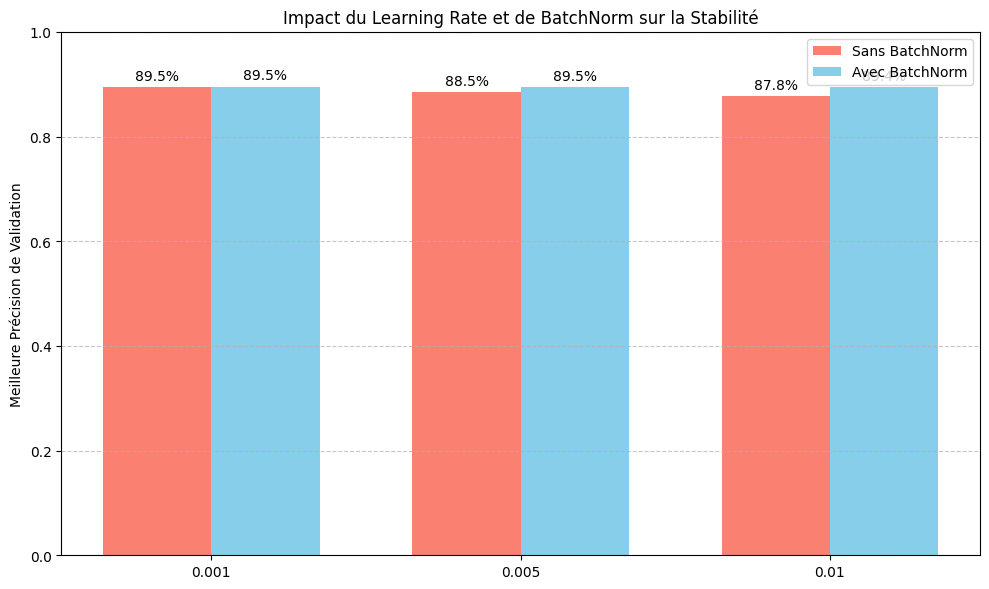

In [13]:
# Définition des paramètres de l'expérience
learning_rates = [1e-3, 5e-3, 1e-2]
configs = {'Sans BN': False, 'Avec BN': True}
resultats_todo7 = {k: [] for k in configs.keys()}

criterion = nn.CrossEntropyLoss()

for nom_config, utilise_bn in configs.items():
    for lr in learning_rates:
        print(f"Entraînement : {nom_config} | LR = {lr}")
        # On réutilise la classe MLP_Full du TODO 5
        model = MLP_Full(use_bn=utilise_bn, use_dropout=False).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        best_acc = 0
        is_nan = False

        for epoch in range(15):
            model.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(x)
                loss = criterion(out, y)

                # Vérification de la divergence (explosion du gradient)
                if torch.isnan(loss):
                    is_nan = True
                    break

                loss.backward()
                optimizer.step()

            if is_nan:
                break

            # Évaluation à la fin de l'époque
            acc_actuelle = evaluate_model(model, val_loader, mode='eval')
            if acc_actuelle > best_acc:
                best_acc = acc_actuelle

        # Enregistrement des résultats (np.nan si divergence)
        valeur_finale = np.nan if is_nan else best_acc
        resultats_todo7[nom_config].append(valeur_finale)
        print(f"-> Meilleure précision : {'NaN' if is_nan else f'{valeur_finale:.2%}'}\n")

# --- Création du graphique à barres groupées ---
x = np.arange(len(learning_rates))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, resultats_todo7['Sans BN'], width, label='Sans BatchNorm', color='salmon')
rects2 = ax.bar(x + width/2, resultats_todo7['Avec BN'], width, label='Avec BatchNorm', color='skyblue')

ax.set_ylabel('Meilleure Précision de Validation')
ax.set_title('Impact du Learning Rate et de BatchNorm sur la Stabilité')
ax.set_xticks(x)
ax.set_xticklabels([f"{lr}" for lr in learning_rates])
ax.legend()

# Fonction pour ajouter les étiquettes (et gérer l'affichage des NaN)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if np.isnan(height):
            # Annoter les configurations qui ont divergé avec "NaN"
            ax.annotate('NaN (Divergence)',
                        xy=(rect.get_x() + rect.get_width() / 2, 0.05),
                        ha='center', va='bottom', color='red', weight='bold', rotation=90)
        else:
            # Afficher la précision pour les modèles stables
            ax.annotate(f'{height:.1%}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # décalage vertical
                        textcoords="offset points",
                        ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Assessment Questions - Exercise 3

#### **Q7.** BatchNorm allowed higher learning rates. Relate this to Santurkar et al. (2018): what property of the loss surface does BatchNorm improve, and how does it affect the maximum stable learning rate?

**Réponse :** Selon Santurkar et al. (2018), BatchNorm rend le paysage de perte beaucoup plus **lisse (smooths the loss landscape)** en limitant la variation des gradients (Lipschitz continuity). Cela empêche les gradients d'exploser ou de changer de direction de manière imprévisible. Un paysage plus lisse autorise des pas de descente plus grands en toute sécurité, augmentant ainsi le taux d'apprentissage maximal stable.



#### **Q8.** Removing `model.eval()` dropped accuracy. Explain precisely what goes wrong: what statistics does BatchNorm use in train mode vs. eval mode, and why are batch statistics unreliable at inference?

**Réponse :** En mode `train()`, BatchNorm normalise les données en utilisant la moyenne et la variance **du mini-batch en cours**. En mode `eval()`, il utilise les statistiques globales (running stats) accumulées pendant tout l'entraînement. À l'inférence, la taille du batch peut être petite (voire 1) ou ne pas représenter du tout la distribution d'entraînement. Utiliser les statistiques instables du batch de test (en oubliant `eval()`) fausse complètement la normalisation et ruine les prédictions.



#### **Q9.** Dropout ($p=0.5$) uses different sub-networks each forward pass. At inference, activations are scaled by $p$ instead of dropping. Why is this scaling necessary for consistent outputs?

**Réponse :** Pendant l'entraînement avec $p=0.5$, la moitié des neurones sont éteints, donc l'intensité globale du signal passant à la couche suivante est divisée par deux. À l'inférence, tous les neurones sont actifs. Si on ne multiplie pas les signaux sortants par $p$ (scaling), la couche suivante recevrait un signal deux fois plus fort que ce qu'elle a "appris" à gérer pendant l'entraînement, ce qui dégraderait les prédictions. *(Note : PyTorch gère cela via l'"inverted dropout" en divisant par p à l'entraînement, mais le principe de conservation d'échelle reste le même).*


####**Q10.** You used `weight_decay=0.01` in AdamW. Is this L2 regularization or decoupled weight decay? What is the difference, and why does it matter for adaptive optimizers like Adam?

**Réponse :** Il s'agit du **decoupled weight decay**. Dans l'Adam classique (L2 regularization), la pénalité est ajoutée au gradient, puis divisée par la variance mobile. Cela perturbe l'effet de la régularisation, surtout pour les poids avec de forts gradients. AdamW "découple" cette étape en soustrayant le weight decay directement aux poids **après** le calcul du gradient adaptatif, ce qui restaure la véritable fonction mathématique de la régularisation et améliore la généralisation.